# 6. Modelagem — Classificação por threshold

Sexta etapa do trabalho, ainda dentro da fase de *Modeling* do CRISP-DM. A pergunta original era se o NPS poderia ser previsto com base em dados operacionais. No notebook anterior respondi com uma regressão linear simples, que entrega um valor numérico de 0 a 10. Aqui dou o passo seguinte: transformar esse valor numérico em uma decisão binária — o cliente vai ser detrator ou não?

Esse formato é mais útil para a operação. Um gerente de SAC não precisa saber se o NPS predito é 5,4 ou 6,2; ele precisa saber se aquele pedido merece um contato proativo ou não. A regra para virar a régua é direta: defino um corte (`threshold`) e classifico como detrator todo cliente cujo NPS predito ficar abaixo desse corte.

A diferença entre este notebook e o anterior é só de leitura. Não treino nenhum modelo novo: reaproveito a regressão do notebook 05 e estudo o efeito de variar o threshold sobre as métricas de classificação.


## 6.1 Carregamento e setup

Mesmo padrão dos notebooks anteriores. Carrego o dataset processado pela função do módulo `src/nps/data.py`, configuro o tema visual e defino os caminhos de saída para figuras desta fase.


In [1]:
# Bibliotecas principais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Modelo e metricas
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# Funcoes do nosso modulo
from nps.data import carregar_dataset_processado

# Reprodutibilidade
SEMENTE_ALEATORIA = 42
np.random.seed(SEMENTE_ALEATORIA)

# Configuracao visual
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# Cores semanticas reaproveitadas do projeto
cores_buckets = {"detrator": "#e74c3c", "neutro": "#95a5a6", "promotor": "#27ae60"}

# Caminhos para esse notebook
RAIZ_PROJETO = Path.cwd().parent
PASTA_FIGURAS = RAIZ_PROJETO / "reports" / "figures" / "06_modelagem_classificacao"
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

# Carrega o dataset processado
dados = carregar_dataset_processado()

print(f"Dataset carregado: {dados.shape[0]:,} linhas x {dados.shape[1]} colunas")


Dataset carregado: 2,500 linhas x 23 colunas


Tudo carregado. A próxima seção define o que significa "ser detrator" no contexto deste notebook e olha como essa classe se distribui na base.


## 6.2 Definição do target binário

A regra original do NPS define três grupos: detrator (nota 0–6), neutro (7–8) e promotor (9–10). Para classificação binária, junto neutros e promotores em uma única classe "não-detrator". A justificativa de negócio é simples: a operação quer saber em quem agir antes que o cliente vire reclamação. Neutros e promotores não precisam de ação imediata; detratores sim.

O target final é uma variável `eh_detrator` que vale 1 quando `nps_score < 7` e 0 caso contrário.


In [2]:
# Target binario: 1 = detrator, 0 = nao-detrator
dados["eh_detrator"] = (dados["nps_score"] < 7).astype(int)

# Distribuicao
contagem = dados["eh_detrator"].value_counts().rename({0: "Nao-detrator", 1: "Detrator"})
proporcao = dados["eh_detrator"].value_counts(normalize=True).rename({0: "Nao-detrator", 1: "Detrator"})

tabela = pd.DataFrame({
    "Quantidade": contagem,
    "Proporcao": proporcao.map(lambda x: f"{x:.1%}"),
})
print(tabela)


              Quantidade Proporcao
eh_detrator                       
Detrator            2109     84.4%
Nao-detrator         391     15.6%


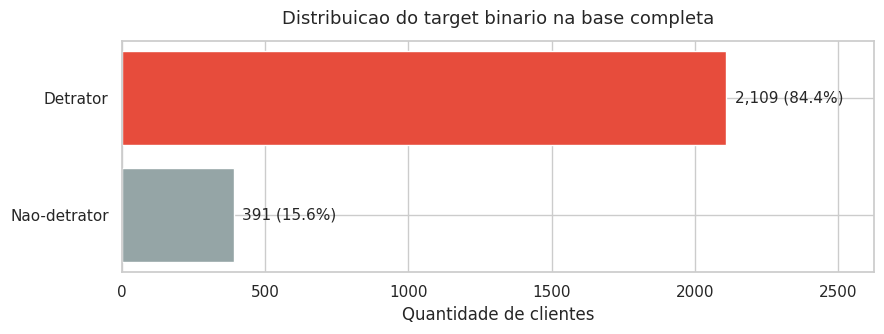

In [3]:
# Grafico de barras horizontal mostrando o desbalanceamento
fig, ax = plt.subplots(figsize=(9, 3.5))

qtd_det = (dados["eh_detrator"] == 1).sum()
qtd_nao = (dados["eh_detrator"] == 0).sum()
total = len(dados)

ax.barh(["Detrator", "Nao-detrator"],
        [qtd_det, qtd_nao],
        color=[cores_buckets["detrator"], cores_buckets["neutro"]],
        edgecolor="white")

# Anotacoes nas barras
for i, (qtd, label) in enumerate(zip([qtd_det, qtd_nao], ["Detrator", "Nao-detrator"])):
    ax.text(qtd + 30, i, f"{qtd:,} ({qtd/total:.1%})", va="center", fontsize=11)

ax.set_xlim(0, total * 1.05)
ax.set_xlabel("Quantidade de clientes")
ax.set_title("Distribuicao do target binario na base completa", fontsize=13, pad=12)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(PASTA_FIGURAS / "6_2_distribuicao_target.png", dpi=120, bbox_inches="tight")
plt.show()


![Distribuição do target binário detrator vs não-detrator](../reports/figures/06_modelagem_classificacao/6_2_distribuicao_target.png)


**Como ler este gráfico:** o eixo Y mostra as duas classes do target binário (detrator em vermelho, não-detrator em cinza). O eixo X é a quantidade de clientes em cada classe, com o número absoluto e a proporção anotados ao lado de cada barra. As cores são as mesmas usadas em todo o projeto: vermelho para detrator, cinza para não-detrator (que aqui agrega neutros e promotores).

A leitura é direta: a base é fortemente desbalanceada. Cerca de 85% dos clientes são detratores e 15% não são. Esse desbalanceamento tem uma consequência imediata para o trabalho de classificação: se eu fizer um modelo trivial que prevê "detrator" para todo mundo, sem olhar nenhuma variável, ele acerta 85% das vezes. Esse vai ser o **baseline** que qualquer threshold precisa superar para fazer sentido.

A próxima seção reaproveita o modelo de regressão do notebook 05 para gerar predições, e a seção 6.4 começa a comparar essas predições com o baseline trivial.


## 6.3 Modelo de regressão e geração das predições

Reproduzo o split e o ajuste do notebook 05 com a mesma semente, então o conjunto de teste deste notebook é exatamente o mesmo do anterior. Isso é importante porque qualquer comparação que eu fizer entre regressão e classificação precisa estar olhando para os mesmos 500 clientes.


In [4]:
# Variavel preditora (X) e target numerico (y)
X = dados[["delivery_delay_days"]]
y = dados["nps_score"]

# Mesmo split do notebook 05
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEMENTE_ALEATORIA,
)

# Ajusta a regressao no treino
dados_treino = pd.concat([X_treino, y_treino], axis=1)
modelo = smf.ols("nps_score ~ delivery_delay_days", data=dados_treino).fit()

# Predicoes no teste
dados_teste = pd.concat([X_teste, y_teste], axis=1)
nps_predito_teste = modelo.predict(dados_teste)

# Target binario observado no teste
y_real_det = (y_teste < 7).astype(int).reset_index(drop=True)
nps_predito_teste = nps_predito_teste.reset_index(drop=True)

print(f"Equacao da reta: nps_predito = {modelo.params['Intercept']:.3f} + ({modelo.params['delivery_delay_days']:.3f}) * delivery_delay_days")
print(f"Tamanho do conjunto de teste: {len(y_teste):,} clientes")
print(f"Detratores reais no teste:    {y_real_det.sum():,} ({y_real_det.mean():.1%})")
print(f"NPS predito range no teste:   {nps_predito_teste.min():.2f} a {nps_predito_teste.max():.2f}")


Equacao da reta: nps_predito = 6.628 + (-1.024) * delivery_delay_days
Tamanho do conjunto de teste: 500 clientes
Detratores reais no teste:    427 (85.4%)
NPS predito range no teste:   -1.57 a 6.63


Atenção a um detalhe que vai virar peça-chave da próxima seção. O **intercepto da regressão é 6,63**, ou seja, a previsão para um cliente com zero dias de atraso já fica abaixo de 7. E o coeficiente é negativo: cada dia adicional de atraso joga a previsão ainda mais para baixo. Isso significa que **todo cliente, independente do atraso, recebe um NPS predito menor que 7**. Esse fato vai determinar o que acontece com o threshold "óbvio" de 7.


## 6.4 O threshold "óbvio" de 7 e por que ele falha

A primeira escolha intuitiva de threshold é 7, exatamente o corte canônico do NPS (notas abaixo de 7 são detratores). Mas como o intercepto da regressão já está em 6,63, **nenhum cliente recebe predição maior ou igual a 7**. Isso transforma o classificador com threshold 7 em algo equivalente a "chutar detrator para todo mundo".

Vou aplicar o threshold de 7 no conjunto de teste, montar a matriz de confusão e comparar com o baseline trivial para deixar isso explícito.


In [5]:
# Aplica threshold = 7
threshold_obvio = 7.0
y_pred_det_t7 = (nps_predito_teste < threshold_obvio).astype(int)

# Metricas
acc_t7 = accuracy_score(y_real_det, y_pred_det_t7)
prec_t7 = precision_score(y_real_det, y_pred_det_t7, zero_division=0)
rec_t7 = recall_score(y_real_det, y_pred_det_t7, zero_division=0)
f1_t7 = f1_score(y_real_det, y_pred_det_t7, zero_division=0)

# Baseline trivial: chuta detrator para todos
y_pred_baseline = np.ones_like(y_real_det)
acc_baseline = accuracy_score(y_real_det, y_pred_baseline)

# Matriz de confusao
cm = confusion_matrix(y_real_det, y_pred_det_t7, labels=[1, 0])
tabela_cm = pd.DataFrame(
    cm,
    index=["Detrator real", "Nao-detrator real"],
    columns=["Predito detrator", "Predito nao-detrator"],
)

print("Matriz de confusao (threshold = 7):")
print(tabela_cm)
print()
print(f"Acuracia do classificador (t=7):  {acc_t7:.3f}")
print(f"Acuracia do baseline trivial:     {acc_baseline:.3f}")
print(f"Precisao (det. preditos que acertam): {prec_t7:.3f}")
print(f"Recall (det. reais capturados):       {rec_t7:.3f}")
print(f"F1:                                   {f1_t7:.3f}")


Matriz de confusao (threshold = 7):
                   Predito detrator  Predito nao-detrator
Detrator real                   427                     0
Nao-detrator real                73                     0

Acuracia do classificador (t=7):  0.854
Acuracia do baseline trivial:     0.854
Precisao (det. preditos que acertam): 0.854
Recall (det. reais capturados):       1.000
F1:                                   0.921


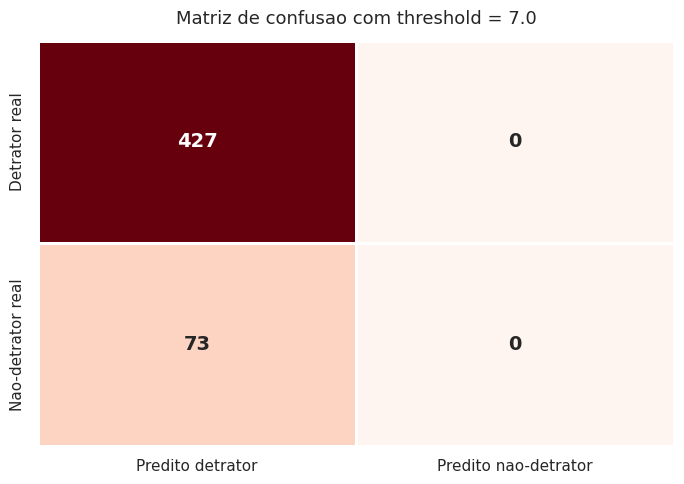

In [6]:
# Heatmap da matriz de confusao
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    tabela_cm,
    annot=True,
    fmt=",d",
    cmap="Reds",
    cbar=False,
    linewidths=1,
    linecolor="white",
    annot_kws={"fontsize": 14, "fontweight": "bold"},
    ax=ax,
)
ax.set_title(f"Matriz de confusao com threshold = {threshold_obvio}", fontsize=13, pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(PASTA_FIGURAS / "6_4_matriz_confusao_t7.png", dpi=120, bbox_inches="tight")
plt.show()


![Matriz de confusão com threshold igual a 7](../reports/figures/06_modelagem_classificacao/6_4_matriz_confusao_t7.png)


**Como ler este gráfico:** uma matriz de confusão tem quatro caixas. As linhas representam o que **aconteceu de verdade** (cliente foi detrator ou não); as colunas representam o que o **modelo previu**. A diagonal principal é onde o modelo acertou: detrator real classificado como detrator (canto superior esquerdo) e não-detrator real classificado como não-detrator (canto inferior direito). A diagonal secundária é onde ele errou.

Os números nas caixas são quantidades absolutas de clientes. Quanto mais escuro o vermelho, maior o valor. A leitura crucial aqui é a coluna direita: ela está vazia. Com threshold 7, **o modelo nunca prediz "não-detrator"** — todas as previsões caem na coluna esquerda.

Olhando os números:

- 427 detratores reais foram preditos como detrator (acerto).
- 73 não-detratores reais também foram preditos como detrator (erro).
- Zero clientes foram preditos como não-detrator.

A acurácia de 85,4% bate exatamente com o baseline trivial. Isso confirma que o threshold 7 não está usando a informação da regressão para nada útil em termos de classificação: ele só replica o palpite ingênuo "todo mundo é detrator". O recall é 100% (capturei todos os detratores), mas pago o preço de não conseguir poupar ninguém: a operação teria que tratar os 500 clientes do teste como se todos fossem detratores.

Para o classificador agregar valor real, o threshold precisa ser **mais conservador**. Em outras palavras, exigir um NPS predito *bem* baixo antes de chamar o cliente de detrator. Isso é o que a próxima seção investiga.
